# Quickstart — Running Qwen 3 VL
Localize every flower in the frame using the Qwen 3 VL model.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ericpence/perceptron_repo/blob/main/cookbook/quickstart/qwen/quickstart_qwen.ipynb)


## Install dependencies
Install the SDK plus helpers for environment loading and visualization.

In [ ]:
!uv pip install --upgrade perceptron pillow

## Prerequisites
1. Generate an API key at https://platform.perceptron.inc.
2. Export it in your terminal before running this notebook:
   - macOS / Linux (bash/zsh)
     ```bash
     export PERCEPTRON_API_KEY="sk-your-key"
     ```
   - Windows (PowerShell)
     ```powershell
     setx PERCEPTRON_API_KEY "sk-your-key"
     ```


## Configure the Perceptron client
Load your API key from the environment (or `.env`) and configure the SDK once for the rest of the notebook.

In [ ]:
import os
from pathlib import Path

from urllib.request import urlretrieve
from IPython.display import Image as IPyImage
from IPython.display import display
from PIL import Image, ImageDraw

from perceptron import configure, image, perceive, text
from perceptron.pointing.geometry import scale_box_to_pixels

PERCEPTRON_API_KEY = os.environ.get("PERCEPTRON_API_KEY", "<your Perceptron API key>")
MODEL_NAME = "qwen3-vl-235b-a22b-thinking"

configure(
    provider="perceptron",
    api_key=PERCEPTRON_API_KEY,
)

IMAGE_URL = "https://raw.githubusercontent.com/perceptron-ai-inc/perceptron/main/cookbook/_shared/assets/quickstart/qwen/flowers.jpg"
IMAGE_PATH = Path("flowers.jpg")
ANNOTATED_PATH = Path("flowers_annotated.jpg")

if not IMAGE_PATH.exists():
    urlretrieve(IMAGE_URL, IMAGE_PATH)


## Detect every flower
Call the reusable `@perceive` helper, then draw the scaled bounding boxes that `scale_box_to_pixels` converts from the 1–1000 grid.

In [ ]:
@perceive(model=MODEL_NAME, expects="box", allow_multiple=True)
def detect_flowers(frame_path: str):
    scene = image(frame_path)
    return scene + text("Localize all of the flowers. Return one bounding box per flower.")


result = detect_flowers(str(IMAGE_PATH))

img = Image.open(IMAGE_PATH).convert("RGB")
draw = ImageDraw.Draw(img)

for idx, box in enumerate(result.points or []):
    scaled = scale_box_to_pixels(box, width=img.width, height=img.height)
    top_left = scaled.top_left
    bottom_right = scaled.bottom_right
    tlx, tly = int(round(top_left.x)), int(round(top_left.y))
    brx, bry = int(round(bottom_right.x)), int(round(bottom_right.y))
    draw.rectangle([tlx, tly, brx, bry], outline="lime", width=3)
    label = box.mention or getattr(box, "label", None) or f"flower {idx + 1}"
    draw.text((tlx, max(tly - 12, 0)), label, fill="lime")

box_count = len(result.points or [])
print(f"Detected {box_count} boxes with {MODEL_NAME}.")

img.save(ANNOTATED_PATH)
print("Annotated image saved to", ANNOTATED_PATH)


Detected 0 boxes with qwen3-vl-235b-a22b-thinking.
Annotated image saved to flowers_annotated.jpg


## View annotated output
Display the saved overlay directly in the notebook so you can confirm grounding without re-running the model.

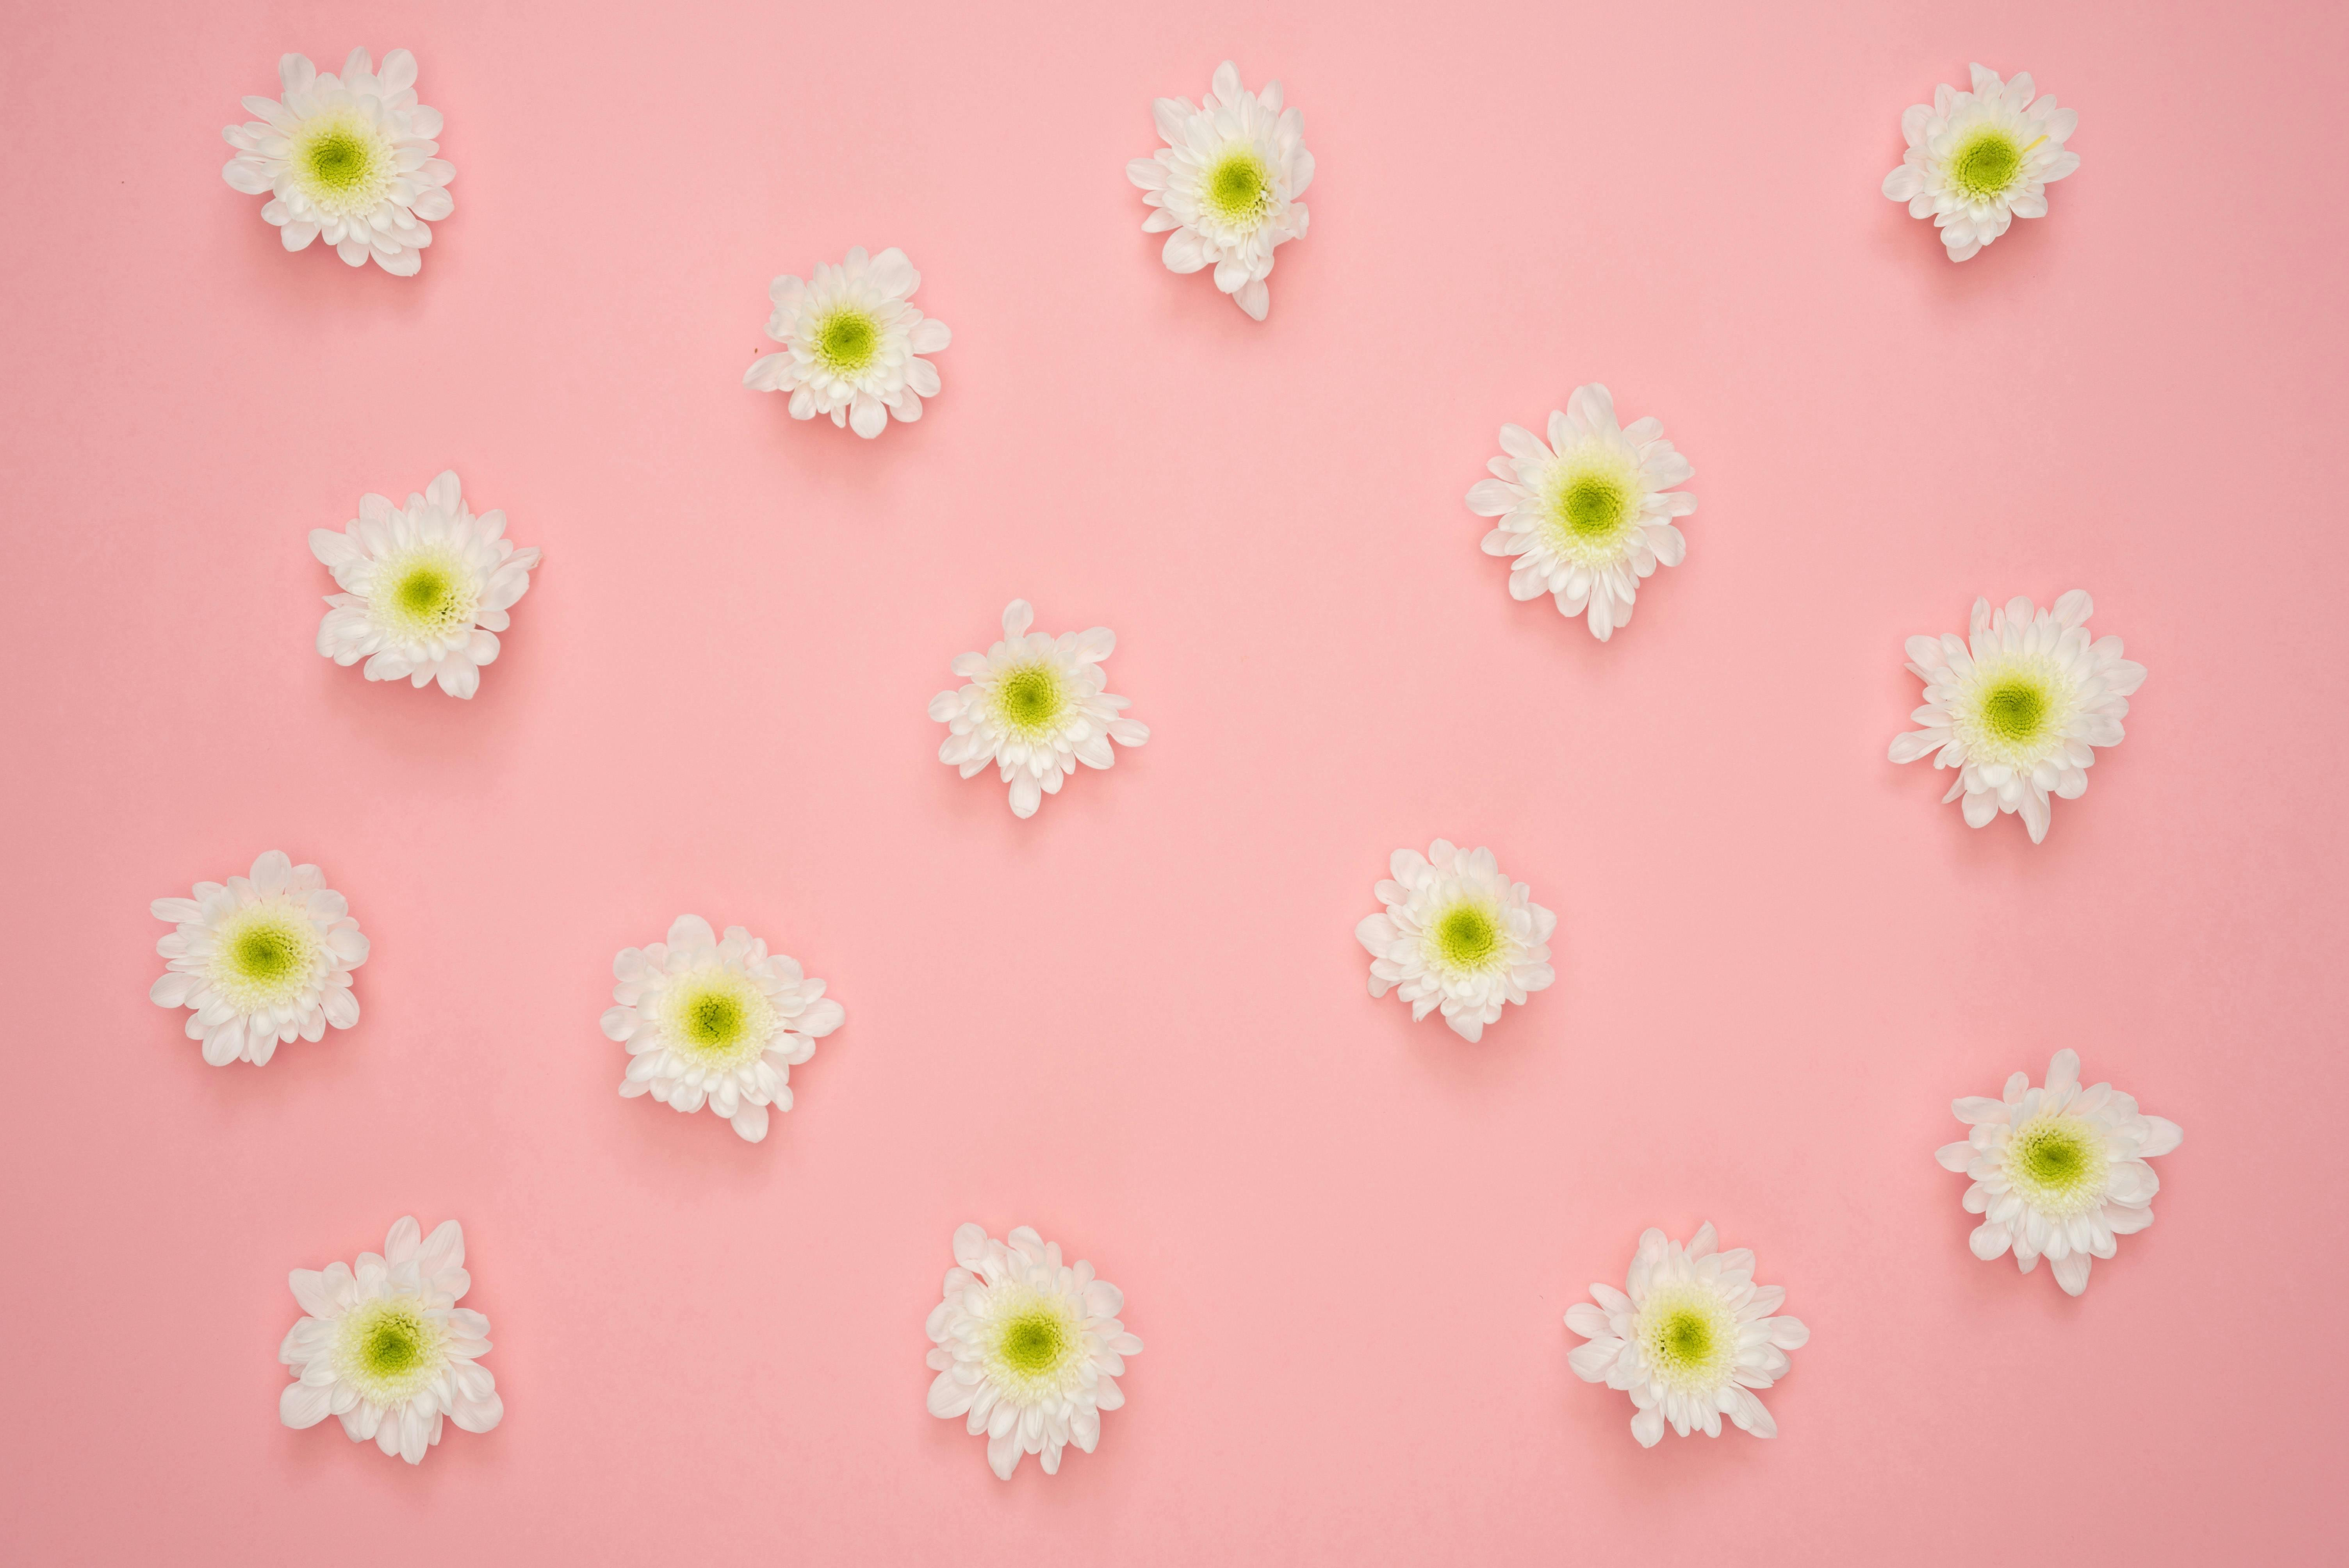

In [5]:
if ANNOTATED_PATH.exists():
    display(IPyImage(filename=str(ANNOTATED_PATH)))
else:
    print("Run the detection cell first to generate the annotated image.")

## Preview the annotated output
Display the saved overlay directly in the notebook so you can confirm grounding without leaving the runtime.

## Conclusion & next steps
- Adjust the prompt or swap `MODEL_NAME` if you need Qwen to localize different concepts.
- Save the `result.points` output for downstream analytics or other cookbook capabilities.
- Embed the visualization snippet into your own tooling to preview detections inline.